# Random-Walk GNN: Training, Validation, and Testing

This notebook mirrors `RWGNN/inference.py` but keeps all outputs inline for easier inspection. It trains a random-walk positional encoding GNN to jointly predict phase and temperature on the BLT dataset, then reports metrics and plots.


## Setup and configuration
Adjust the configuration below if you want to train with different hyperparameters or dataset locations.

In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

# Configuration (mirrors argparse defaults in inference.py)
dataset_dir = Path("blt_rwgnn_dataset")
hidden_dim = 64
num_layers = 3
dropout = 0.1
batch_size = 128
epochs = 400
lr = 1e-3
temp_weight = 1.0
artifact_path = Path("artifacts/rwgnn_model.joblib")
confusion_path = Path("artifacts/confusion_matrix.png")
regression_path = Path("artifacts/temperature_regression.png")
seed = 0

# Reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Data loading
Reads the graph splits produced by `gen_dataset_rwgnn.py` and determines the model input dimensionality.

In [11]:
def load_graph_split(path: Path) -> List:
    graphs = torch.load(path, weights_only=False)
    if not isinstance(graphs, list):
        raise ValueError(f"Expected a list of Data objects in {path}")
    return graphs

metadata_path = dataset_dir / "metadata.json"
if not metadata_path.exists():
    raise FileNotFoundError(f"No metadata.json at {metadata_path}; run gen_dataset_rwgnn.py first.")
metadata: Dict = json.loads(metadata_path.read_text())

train_graphs = load_graph_split(dataset_dir / "train.pt")
val_graphs = load_graph_split(dataset_dir / "val.pt")
test_graphs = load_graph_split(dataset_dir / "test.pt")

walk_length = metadata["walk_length"]
node_feat_dim = metadata.get("features_per_node", 2)
input_dim = node_feat_dim + walk_length

train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

input_dim, len(train_graphs), len(val_graphs), len(test_graphs)


(18, 420, 90, 90)

## Model definition
A simple GCN stack that concatenates spin features with random-walk positional encodings, with two heads: one for phase classification and one for temperature regression.

In [12]:
class RandomWalkGNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.convs = nn.ModuleList()
        for layer_idx in range(num_layers):
            in_dim = input_dim if layer_idx == 0 else hidden_dim
            self.convs.append(GCNConv(in_dim, hidden_dim))
        self.dropout = dropout
        self.phase_head = nn.Linear(hidden_dim, 2)
        self.temp_head = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x = data.x
        if hasattr(data, "rw_pe"):
            x = torch.cat([x, data.rw_pe], dim=-1)
        for conv in self.convs:
            x = conv(x, data.edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, data.batch)
        phase_logits = self.phase_head(x)
        temp_pred = self.temp_head(x).squeeze(-1)
        return phase_logits, temp_pred

model = RandomWalkGNN(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model


RandomWalkGNN(
  (convs): ModuleList(
    (0): GCNConv(18, 64)
    (1-2): 2 x GCNConv(64, 64)
  )
  (phase_head): Linear(in_features=64, out_features=2, bias=True)
  (temp_head): Linear(in_features=64, out_features=1, bias=True)
)

## Training and evaluation helpers

In [13]:
def step_epoch(model, loader, optimizer, device, temp_weight: float) -> float:
    model.train()
    total_loss = 0.0
    total_graphs = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        phase_logits, temp_pred = model(batch)
        cls_loss = F.cross_entropy(phase_logits, batch.y)
        temp_loss = F.mse_loss(temp_pred, batch.temp)
        loss = cls_loss + temp_weight * temp_loss
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * batch.num_graphs
        total_graphs += batch.num_graphs
    return total_loss / max(total_graphs, 1)


def evaluate(model, loader, device) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, float]]:
    model.eval()
    all_logits: List[torch.Tensor] = []
    all_temps: List[torch.Tensor] = []
    all_temp_preds: List[torch.Tensor] = []
    all_labels: List[torch.Tensor] = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            phase_logits, temp_pred = model(batch)
            all_logits.append(phase_logits.cpu())
            all_temps.append(batch.temp.cpu())
            all_temp_preds.append(temp_pred.cpu())
            all_labels.append(batch.y.cpu())

    logits = torch.cat(all_logits)
    temps = torch.cat(all_temps)
    temp_preds = torch.cat(all_temp_preds)
    labels = torch.cat(all_labels)

    probs = torch.softmax(logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    mae = mean_absolute_error(temps, temp_preds)
    rmse = float(np.sqrt(mean_squared_error(temps, temp_preds)))
    metrics = {"accuracy": acc, "f1": f1, "mae": mae, "rmse": rmse}

    return preds.numpy(), temps.numpy(), temp_preds.numpy(), metrics


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Phase confusion matrix")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_temperature_regression(true_t: np.ndarray, pred_t: np.ndarray, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6, 5))
    plt.scatter(true_t, pred_t, alpha=0.6, label="samples")
    slope, intercept = np.polyfit(true_t, pred_t, 1)
    xs = np.linspace(true_t.min(), true_t.max(), 100)
    plt.plot(xs, slope * xs + intercept, color="red", label=f"y={slope:.2f}x+{intercept:.2f}")
    plt.xlabel("True temperature")
    plt.ylabel("Predicted temperature")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()


## Train the model
Runs the training loop and reports validation metrics every ~10% of the epochs.

In [14]:
history = []
for epoch in range(1, epochs + 1):
    loss = step_epoch(model, train_loader, optimizer, device, temp_weight=temp_weight)
    if epoch % max(1, epochs // 10) == 0 or epoch == 1:
        _, _, _, val_metrics = evaluate(model, val_loader, device)
        history.append({"epoch": epoch, "loss": loss, **val_metrics})
        print(
            f"Epoch {epoch}/{epochs} - loss={loss:.4f} "
            f"val_acc={val_metrics['accuracy']:.3f} val_f1={val_metrics['f1']:.3f} "
            f"val_mae={val_metrics['mae']:.4f} val_rmse={val_metrics['rmse']:.4f}"
        )


Epoch 1/50 - loss=1.6795 val_acc=0.511 val_f1=0.676 val_mae=0.8727 val_rmse=0.9433
Epoch 5/50 - loss=1.1330 val_acc=0.489 val_f1=0.000 val_mae=0.4701 val_rmse=0.5740
Epoch 10/50 - loss=0.8817 val_acc=0.489 val_f1=0.000 val_mae=0.3649 val_rmse=0.4232
Epoch 15/50 - loss=0.8565 val_acc=0.600 val_f1=0.379 val_mae=0.3589 val_rmse=0.4115
Epoch 20/50 - loss=0.8468 val_acc=0.489 val_f1=0.000 val_mae=0.3516 val_rmse=0.4028
Epoch 25/50 - loss=0.8366 val_acc=0.667 val_f1=0.516 val_mae=0.3446 val_rmse=0.3936
Epoch 30/50 - loss=0.8211 val_acc=0.711 val_f1=0.606 val_mae=0.3333 val_rmse=0.3804
Epoch 35/50 - loss=0.7978 val_acc=0.722 val_f1=0.627 val_mae=0.3160 val_rmse=0.3608
Epoch 40/50 - loss=0.7635 val_acc=0.767 val_f1=0.704 val_mae=0.2881 val_rmse=0.3299
Epoch 45/50 - loss=0.7021 val_acc=0.878 val_f1=0.867 val_mae=0.2453 val_rmse=0.2832
Epoch 50/50 - loss=0.6017 val_acc=0.867 val_f1=0.850 val_mae=0.1762 val_rmse=0.2080


## Final evaluation
Collects metrics on train/val/test and saves the trained weights and configuration to an artifact for reuse.

In [15]:
def collect_metrics(split: str, loader):
    preds, true_t, pred_t, metrics = evaluate(model, loader, device)
    metrics["split"] = split
    return preds, true_t, pred_t, metrics

train_preds, train_t, train_pred_t, train_metrics = collect_metrics("train", train_loader)
val_preds, val_t, val_pred_t, val_metrics = collect_metrics("val", val_loader)
test_preds, test_t, test_pred_t, test_metrics = collect_metrics("test", test_loader)

for metrics in [train_metrics, val_metrics, test_metrics]:
    print(
        f"[{metrics['split']}] acc={metrics['accuracy']:.3f} f1={metrics['f1']:.3f} "
        f"mae={metrics['mae']:.4f} rmse={metrics['rmse']:.4f}"
    )

artifact = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "input_dim": input_dim,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "temp_weight": temp_weight,
    },
    "optimizer_state_dict": optimizer.state_dict(),
    "metrics": [train_metrics, val_metrics, test_metrics],
    "metadata": metadata,
    "history": history,
}
artifact_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
artifact_path


[train] acc=0.924 f1=0.918 mae=0.1743 rmse=0.2053
[val] acc=0.867 f1=0.850 mae=0.1762 rmse=0.2080
[test] acc=0.878 f1=0.874 mae=0.1738 rmse=0.1984


PosixPath('artifacts/rwgnn_model.joblib')

## Plots
Displays and saves the confusion matrix and the temperature regression fit on the test split.

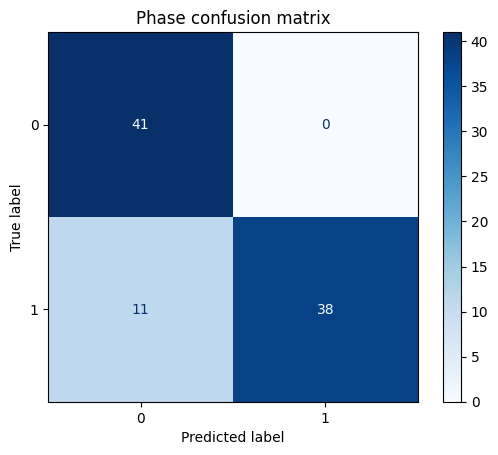

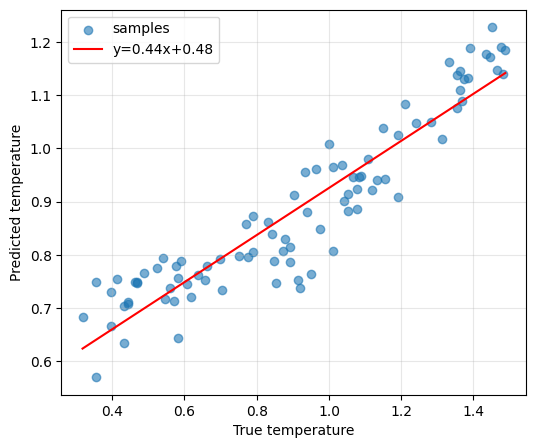

Saved confusion matrix to artifacts/confusion_matrix.png
Saved temperature regression plot to artifacts/temperature_regression.png


In [17]:
y_true_test = np.array([batch.y.cpu().numpy() for batch in test_graphs])
plot_confusion_matrix(y_true_test, test_preds, confusion_path)
plot_temperature_regression(test_t, test_pred_t, regression_path)
print(f"Saved confusion matrix to {confusion_path}")
print(f"Saved temperature regression plot to {regression_path}")
